<a href="https://colab.research.google.com/github/Aswathi-06/Plant_Species_Classification/blob/main/Plant_Species_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import tensorflow as tf
print("GPU available:", tf.config.list_physical_devices('GPU'))

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

In [7]:
import os
project_path = "/content/drive/MyDrive/Plant_Identification_Project"
os.makedirs(project_path, exist_ok=True)
print("Project folder ready at:", project_path)

Project folder ready at: /content/drive/MyDrive/Plant_Identification_Project


In [8]:
from getpass import getpass
import os

os.environ["KAGGLE_API_TOKEN"] = getpass("Paste your Kaggle API token here: ")

Paste your Kaggle API token here: ··········


In [9]:
!pip install -q kaggle

In [10]:
%cd /content/drive/MyDrive/Plant_Identification_Project
!kaggle datasets download -d abdallahalidev/plantvillage-dataset

/content/drive/MyDrive/Plant_Identification_Project
Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:50<00:00, 43.0MB/s]



In [11]:
import os
print(os.listdir("/content/drive/MyDrive/Plant_Identification_Project"))

['plantdisease.zip', 'plant_data', 'plantvillage-dataset.zip']


In [12]:
!unzip -q /content/drive/MyDrive/Plant_Identification_Project/plantvillage-dataset.zip -d /content/plant_data_full

In [13]:
print(os.listdir("/content/plant_data_full"))

['plantvillage dataset']


In [14]:
print(os.listdir("/content/plant_data_full/plantvillage dataset"))

['segmented', 'grayscale', 'color']


In [16]:
import shutil

source = "/content/plant_data_full/plantvillage dataset/color"
destination = "/content/drive/MyDrive/Plant_Identification_Project/plant_data/color"

shutil.copytree(source, destination)
print("Copy complete.")

Copy complete.


In [17]:
import os

plant_data_path = "/content/drive/MyDrive/Plant_Identification_Project/plant_data"
print("Contents of plant_data:", os.listdir(plant_data_path))

color_path = os.path.join(plant_data_path, "color")
classes = sorted(os.listdir(color_path))
print(f"\nNumber of classes: {len(classes)}")
for c in classes:
    print(c)

Contents of plant_data: ['PlantVillage', 'plantvillage', 'color']

Number of classes: 38
Apple___Apple_scab
Apple___Black_rot
Apple___Cedar_apple_rust
Apple___healthy
Blueberry___healthy
Cherry_(including_sour)___Powdery_mildew
Cherry_(including_sour)___healthy
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Corn_(maize)___Northern_Leaf_Blight
Corn_(maize)___healthy
Grape___Black_rot
Grape___Esca_(Black_Measles)
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
Grape___healthy
Orange___Haunglongbing_(Citrus_greening)
Peach___Bacterial_spot
Peach___healthy
Pepper,_bell___Bacterial_spot
Pepper,_bell___healthy
Potato___Early_blight
Potato___Late_blight
Potato___healthy
Raspberry___healthy
Soybean___healthy
Squash___Powdery_mildew
Strawberry___Leaf_scorch
Strawberry___healthy
Tomato___Bacterial_spot
Tomato___Early_blight
Tomato___Late_blight
Tomato___Leaf_Mold
Tomato___Septoria_leaf_spot
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Target_Spot
Tomato___Tom

In [18]:
import shutil

shutil.rmtree("/content/drive/MyDrive/Plant_Identification_Project/plant_data/PlantVillage", ignore_errors=True)
shutil.rmtree("/content/drive/MyDrive/Plant_Identification_Project/plant_data/plantvillage", ignore_errors=True)
print("Old folders removed.")

Old folders removed.


In [20]:
data_dir = "/content/drive/MyDrive/Plant_Identification_Project/plant_data/color"
classes = sorted(os.listdir(data_dir))
print(f"Confirmed: {len(classes)} classes ready to use.")

Confirmed: 38 classes ready to use.


In [21]:
import pandas as pd

counts = {}
for c in classes:
    class_path = os.path.join(data_dir, c)
    counts[c] = len(os.listdir(class_path))

df_counts = pd.DataFrame(list(counts.items()), columns=["class", "image_count"])
df_counts = df_counts.sort_values("image_count", ascending=False)

print(df_counts.to_string(index=False))
print(f"\nTotal images: {df_counts['image_count'].sum()}")
print(f"Min class size: {df_counts['image_count'].min()}  ({df_counts.iloc[-1]['class']})")
print(f"Max class size: {df_counts['image_count'].max()}  ({df_counts.iloc[0]['class']})")

                                             class  image_count
          Orange___Haunglongbing_(Citrus_greening)         5507
            Tomato___Tomato_Yellow_Leaf_Curl_Virus         5357
                                 Soybean___healthy         5090
                            Peach___Bacterial_spot         2297
                           Tomato___Bacterial_spot         2127
                              Tomato___Late_blight         1909
                           Squash___Powdery_mildew         1835
                       Tomato___Septoria_leaf_spot         1771
     Tomato___Spider_mites Two-spotted_spider_mite         1676
                                   Apple___healthy         1645
                                  Tomato___healthy         1591
                               Blueberry___healthy         1502
                            Pepper,_bell___healthy         1478
                              Tomato___Target_Spot         1404
                      Grape___Esca_(Blac

In [22]:
def get_species_from_folder(folder_name):
    """Converts a PlantVillage folder name into just the species name."""
    return folder_name.split("___")[0]

df_counts["species"] = df_counts["class"].apply(get_species_from_folder)
species_counts = df_counts.groupby("species")["image_count"].sum().sort_values(ascending=False)

print(species_counts.to_string())
print(f"\nNumber of species: {len(species_counts)}")
print(f"Min species size: {species_counts.min()}")
print(f"Max species size: {species_counts.max()}")

species
Tomato                     18160
Orange                      5507
Soybean                     5090
Grape                       4062
Corn_(maize)                3852
Apple                       3171
Peach                       2657
Pepper,_bell                2475
Potato                      2152
Cherry_(including_sour)     1906
Squash                      1835
Strawberry                  1565
Blueberry                   1502
Raspberry                    371

Number of species: 14
Min species size: 371
Max species size: 18160


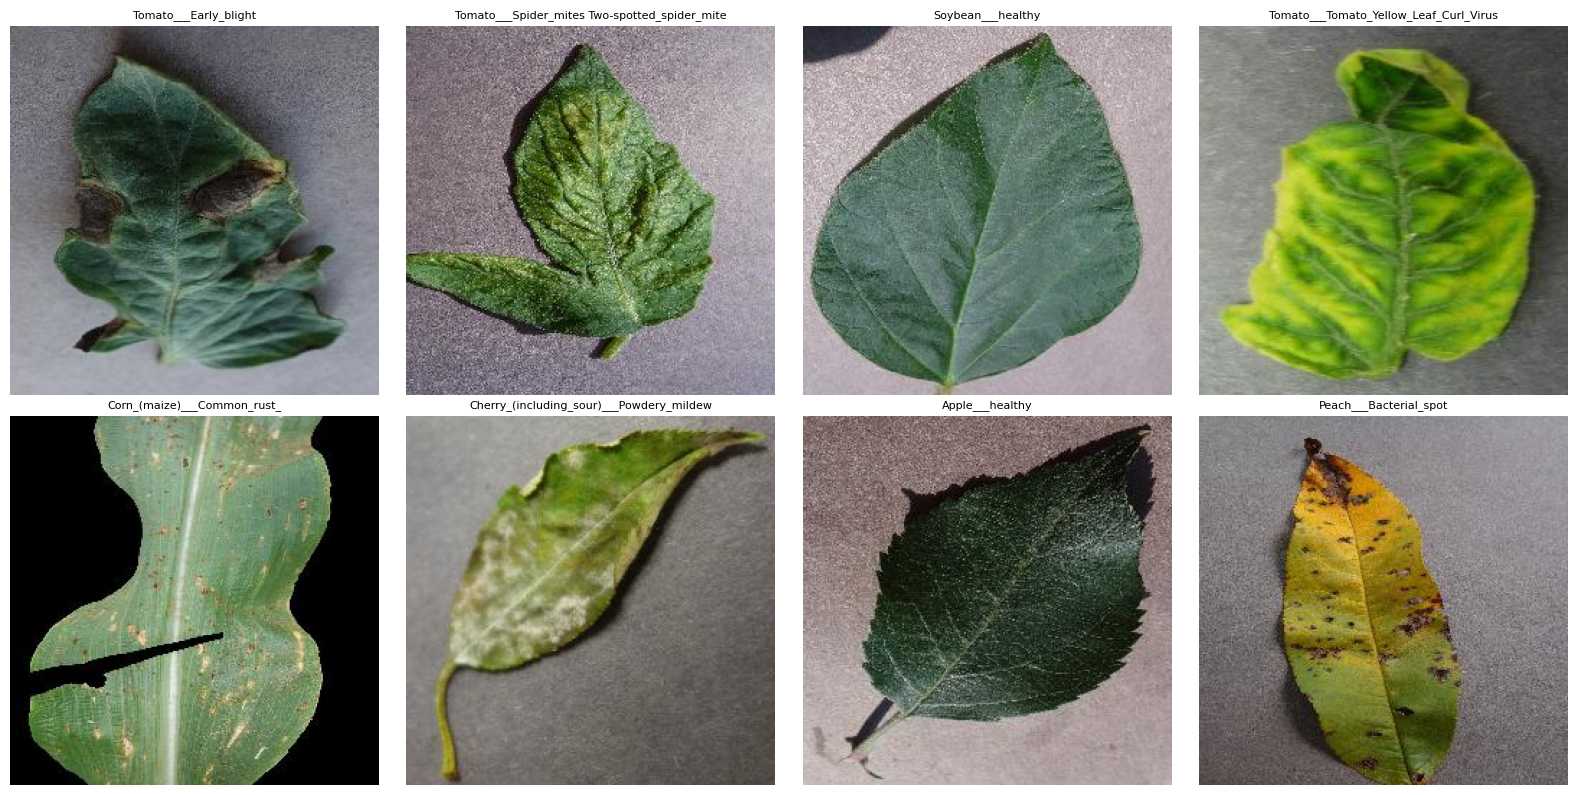

In [23]:
import matplotlib.pyplot as plt
from PIL import Image
import random

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
sample_classes = random.sample(classes, 8)

for ax, cls in zip(axes.flatten(), sample_classes):
    class_path = os.path.join(data_dir, cls)
    img_file = random.choice(os.listdir(class_path))
    img = Image.open(os.path.join(class_path, img_file))
    ax.imshow(img)
    ax.set_title(cls, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

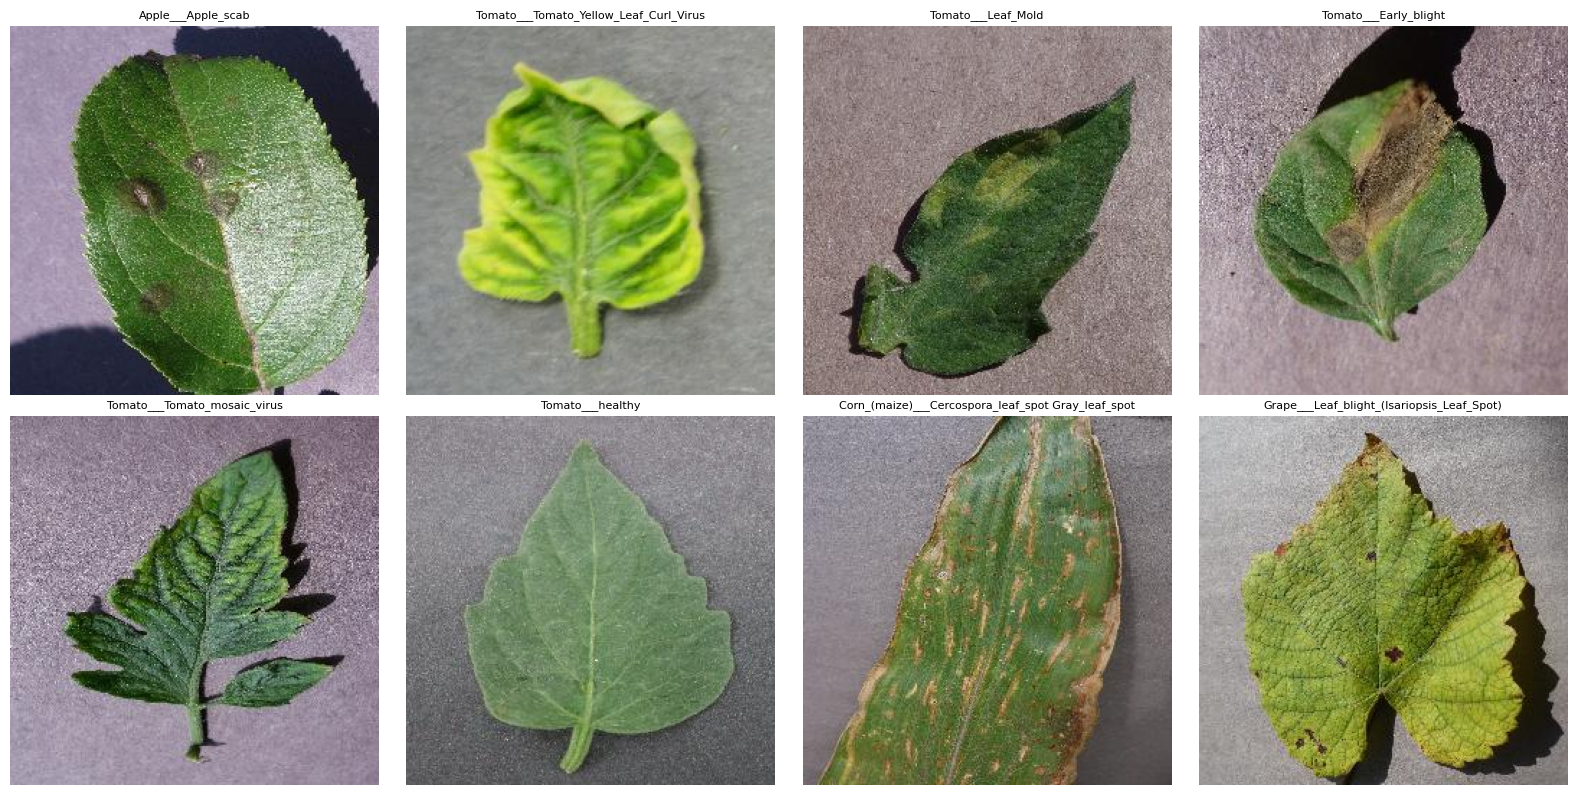

In [24]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
sample_classes = random.sample(classes, 8)

for ax, cls in zip(axes.flatten(), sample_classes):
    class_path = os.path.join(data_dir, cls)
    img_file = random.choice(os.listdir(class_path))
    img = Image.open(os.path.join(class_path, img_file))
    ax.imshow(img)
    ax.set_title(cls, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [25]:
def get_species_from_folder(folder_name):
    """
    Converts a PlantVillage folder name into just the species name.

    PlantVillage folder names follow the pattern: 'Species___Condition'
    e.g. 'Tomato___Early_blight' -> 'Tomato'
         'Apple___healthy'       -> 'Apple'

    We only need the species part for our MVP (species-level identification),
    not the disease/health condition — that's reserved for a future
    disease-detection feature (Phase 2).
    """
    return folder_name.split("___")[0]


# Build a mapping from every one of the 38 original folders to its species
species_map = {folder: get_species_from_folder(folder) for folder in classes}

# Get the unique list of species (removes duplicates automatically)
unique_species = sorted(set(species_map.values()))

print(f"Collapsed {len(classes)} folders into {len(unique_species)} species:\n")
for species in unique_species:
    # Show which original folders map into this species, for transparency
    matching_folders = [f for f, s in species_map.items() if s == species]
    print(f"{species}  <-  {matching_folders}")

Collapsed 38 folders into 14 species:

Apple  <-  ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy']
Blueberry  <-  ['Blueberry___healthy']
Cherry_(including_sour)  <-  ['Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy']
Corn_(maize)  <-  ['Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy']
Grape  <-  ['Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy']
Orange  <-  ['Orange___Haunglongbing_(Citrus_greening)']
Peach  <-  ['Peach___Bacterial_spot', 'Peach___healthy']
Pepper,_bell  <-  ['Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy']
Potato  <-  ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Raspberry  <-  ['Raspberry___healthy']
Soybean  <-  ['Soybean___healthy']
Squash  <-  ['Squash___Powdery_mildew']
Strawberry  <-  ['Stra